## **House Sales Price Prediction Training Part 2**

The last notebook only uses Linear Regression with Gradient Descent along with some feature engineering. However there are a lot more regression techniques we can use for this challenge as additional feature engineering, this notebook will explore that.

The following sections are outlined as follows:
- Cleaning the Data
- Training the Models
- Making Predictions

### **Cleaning the Data**

In [25]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

# Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb

import warnings
warnings.filterwarnings("ignore")

In [26]:
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

In [27]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

Let's first find the numeric columns in our training set:

In [28]:
num_cols = train_data.select_dtypes(include=["int64", "float64"]).columns.to_list()
num_cols.remove("Id")
num_cols.remove("SalePrice")
num_cols

['MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

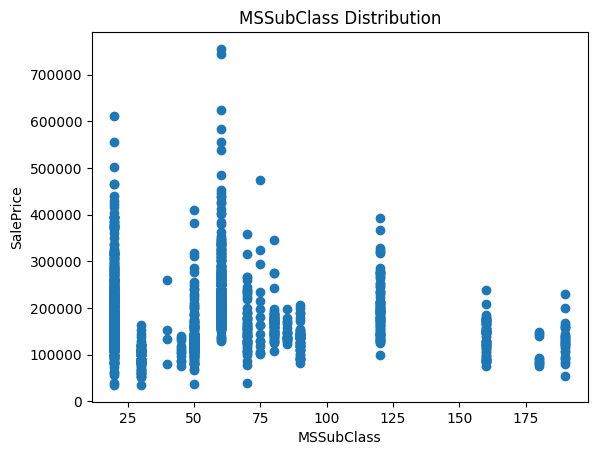

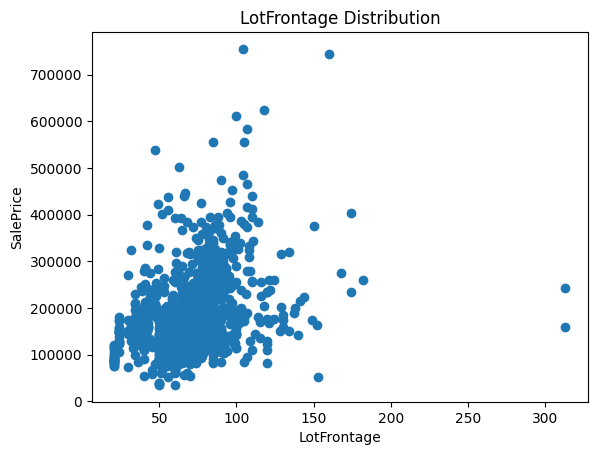

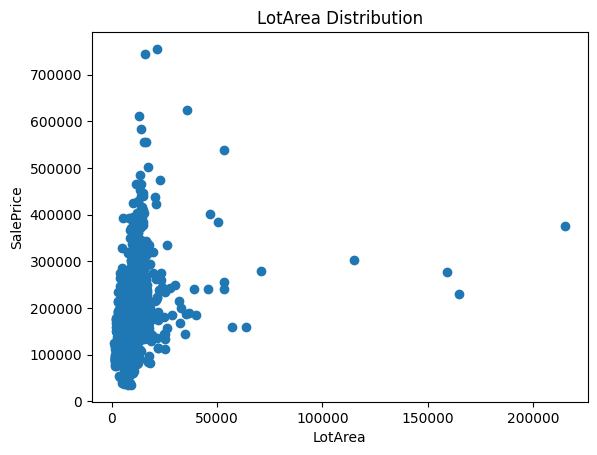

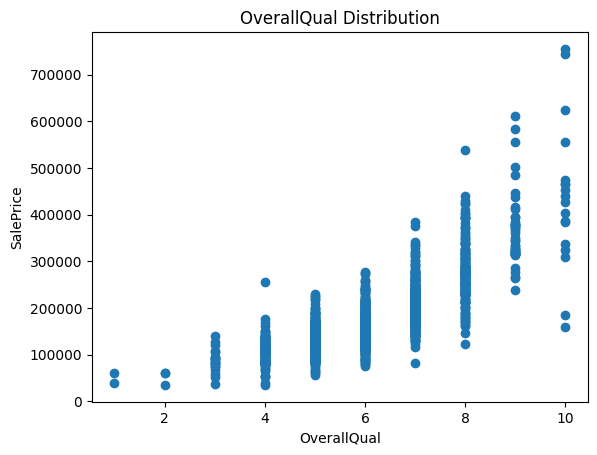

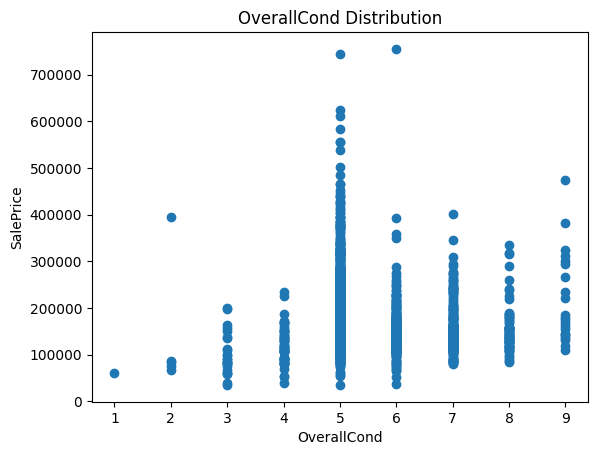

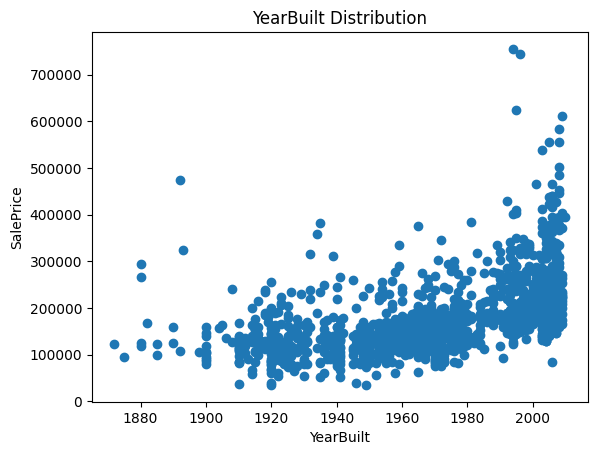

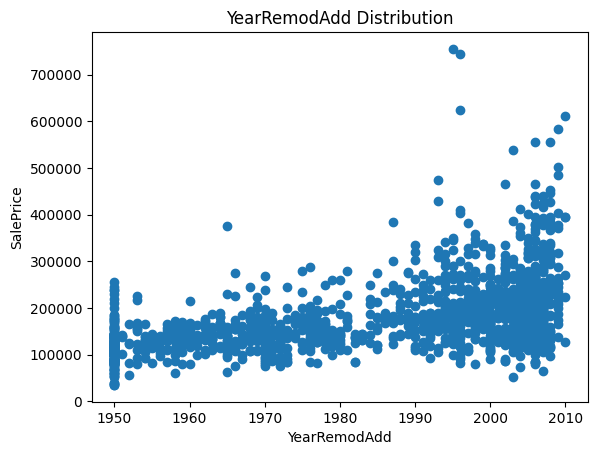

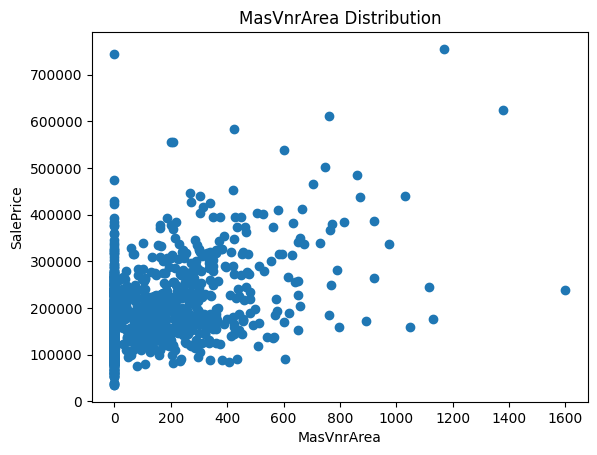

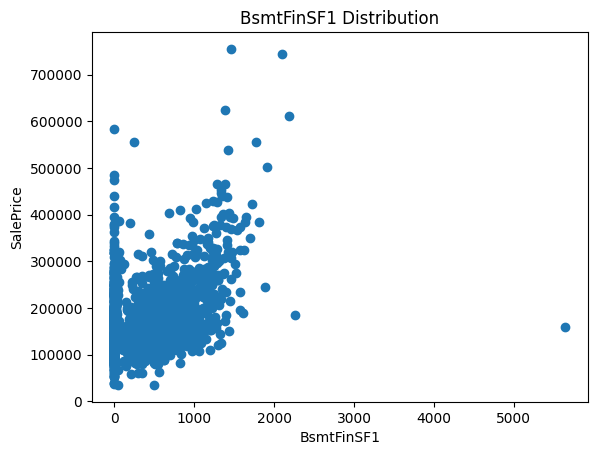

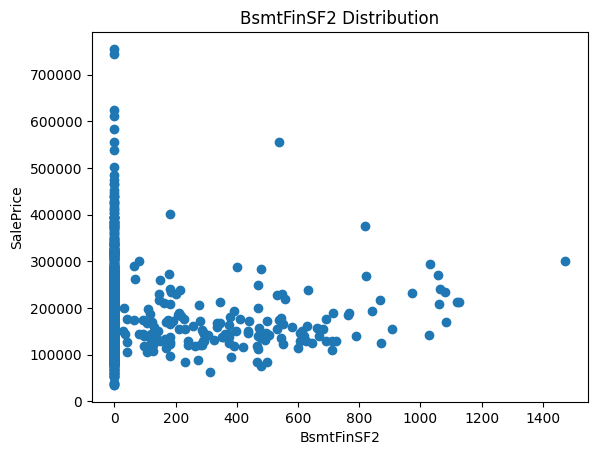

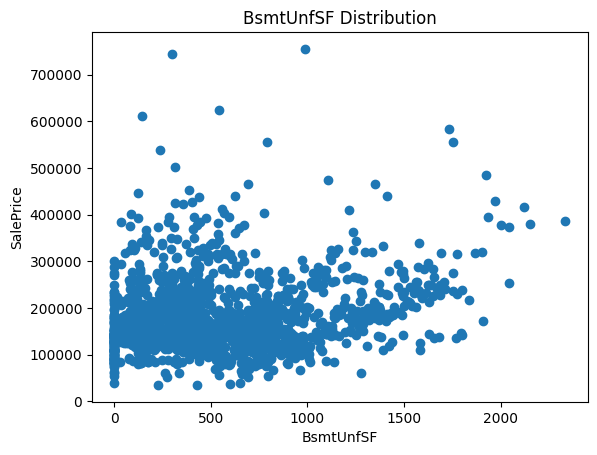

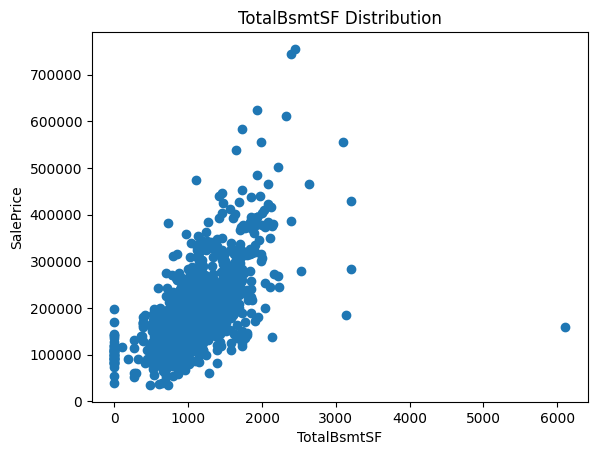

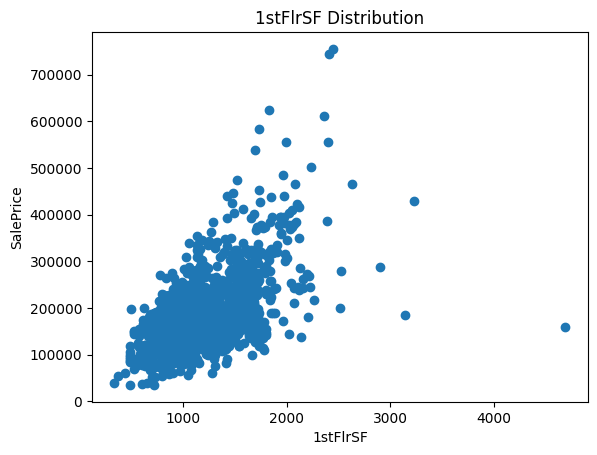

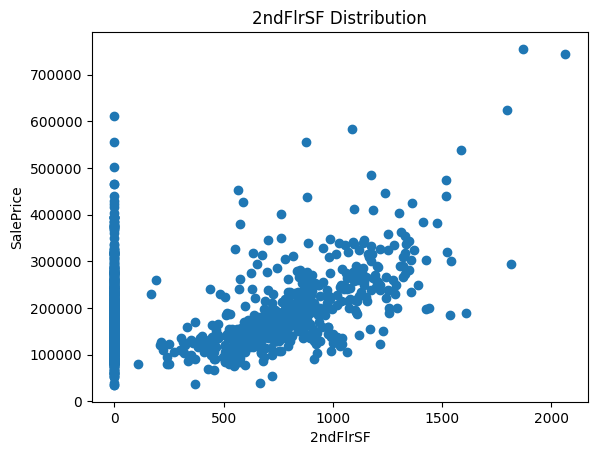

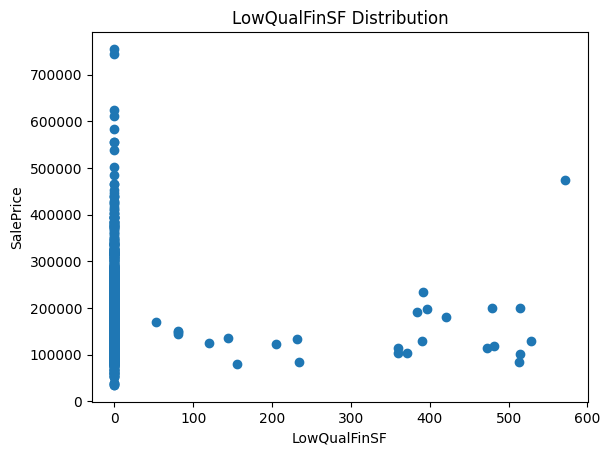

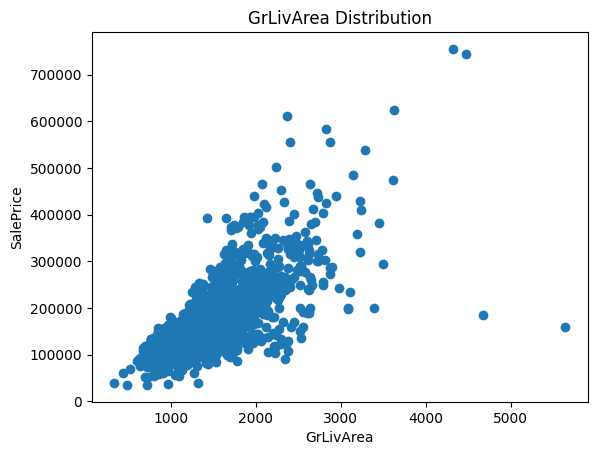

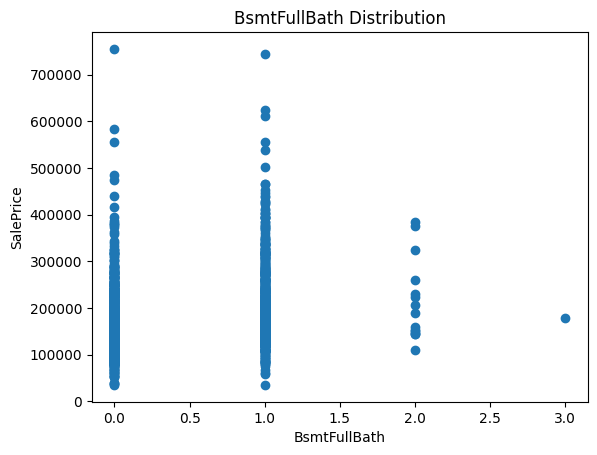

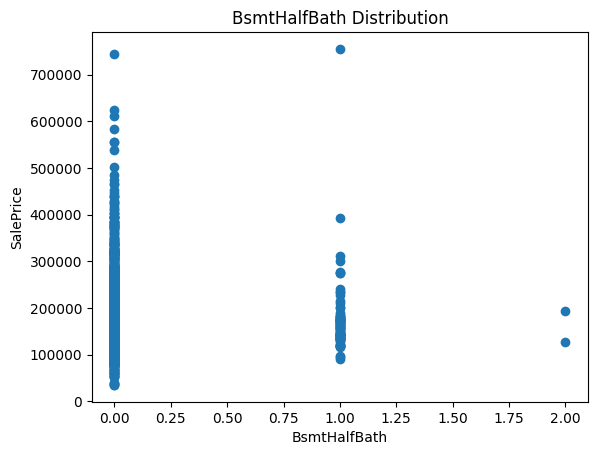

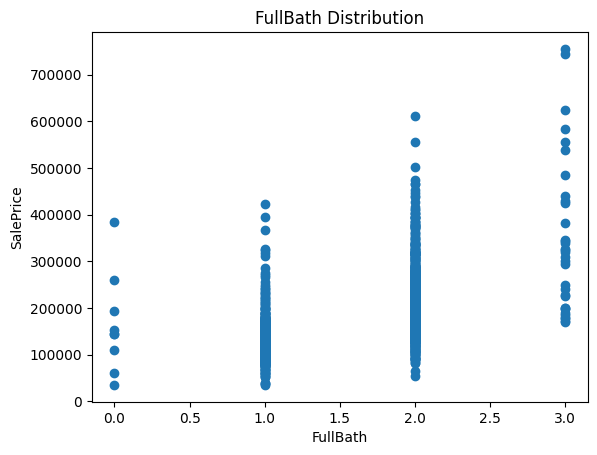

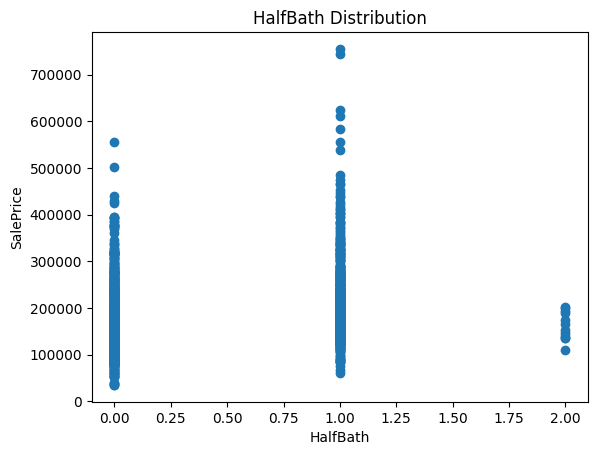

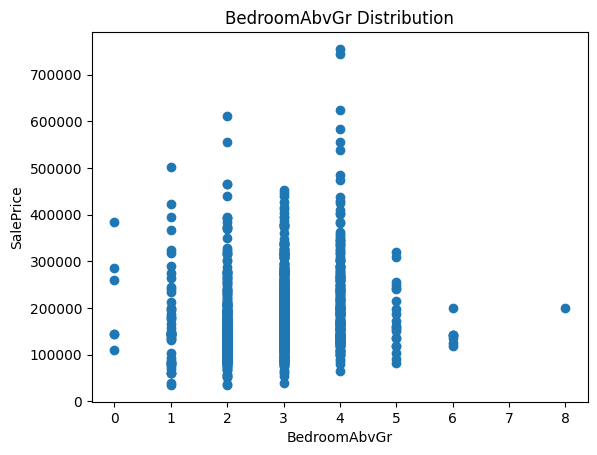

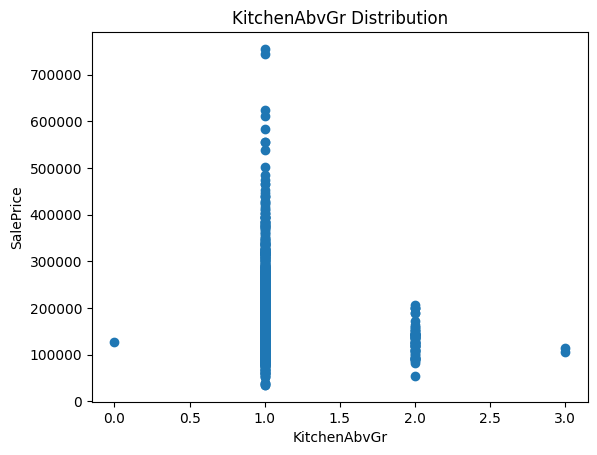

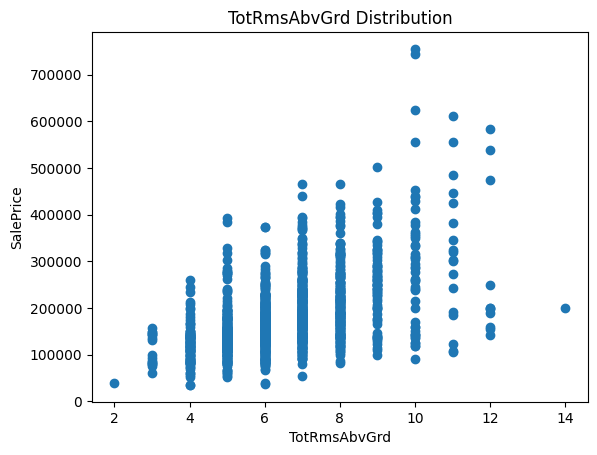

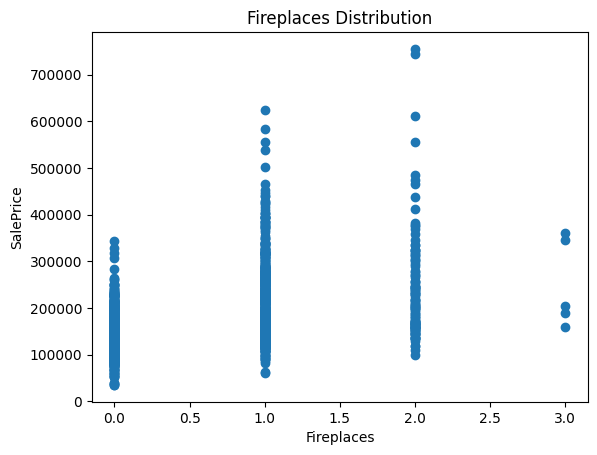

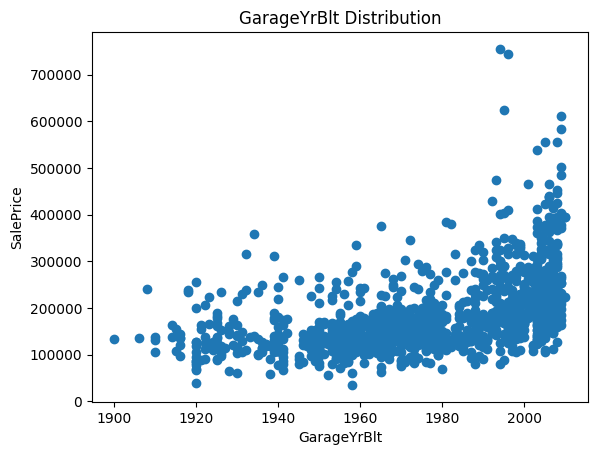

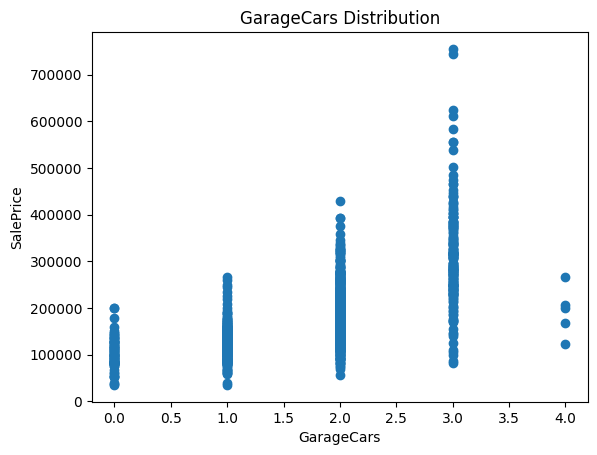

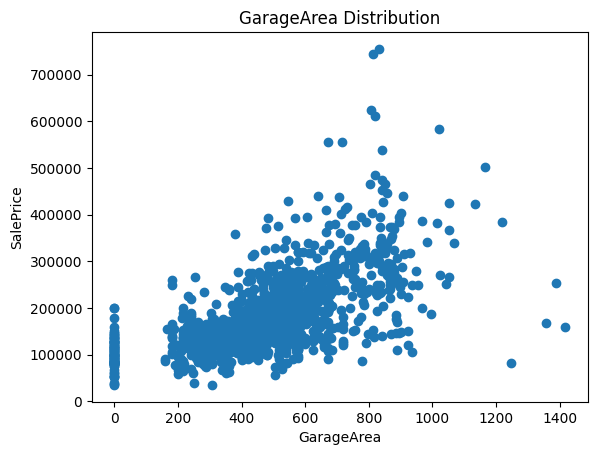

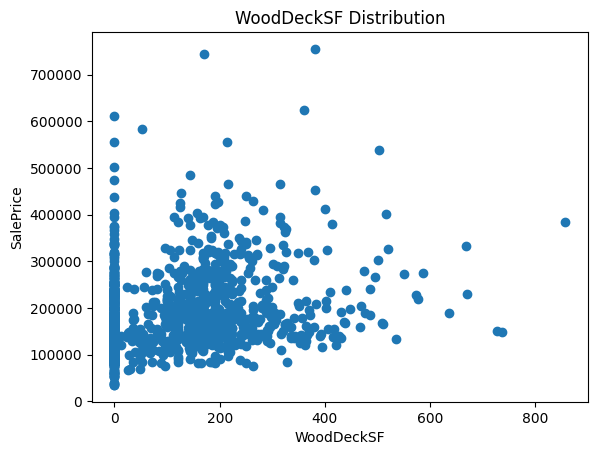

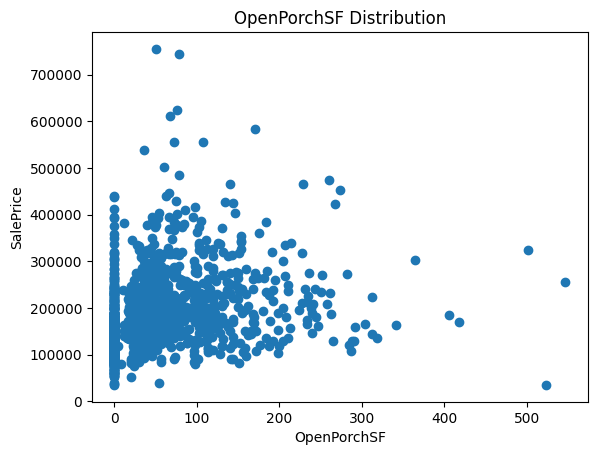

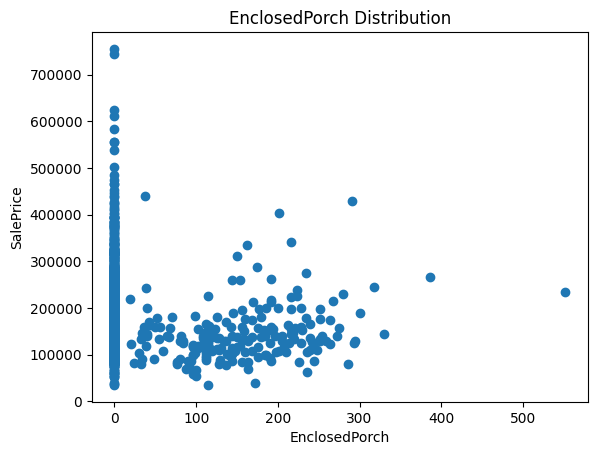

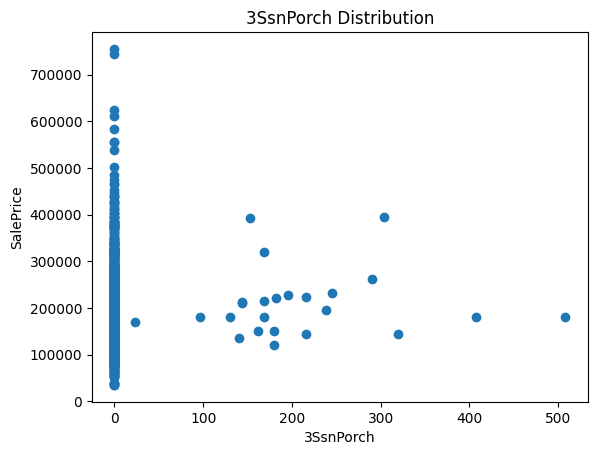

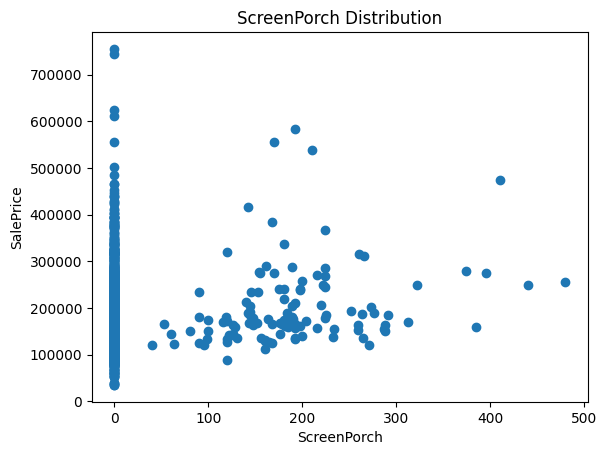

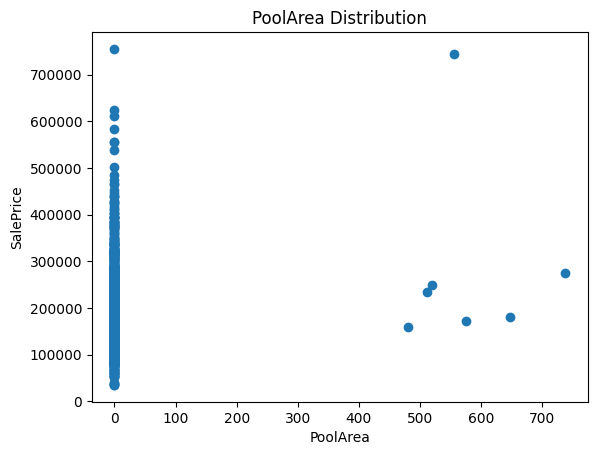

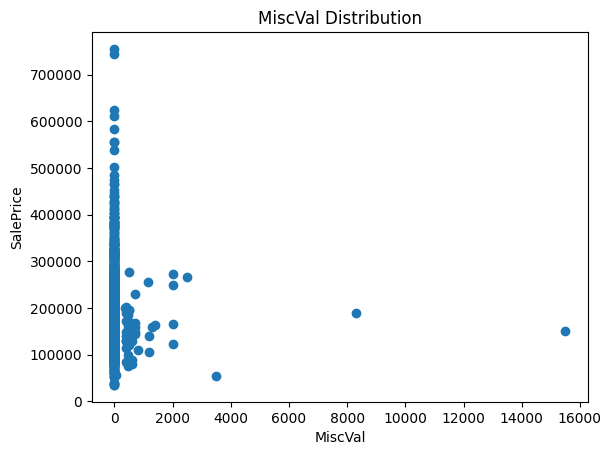

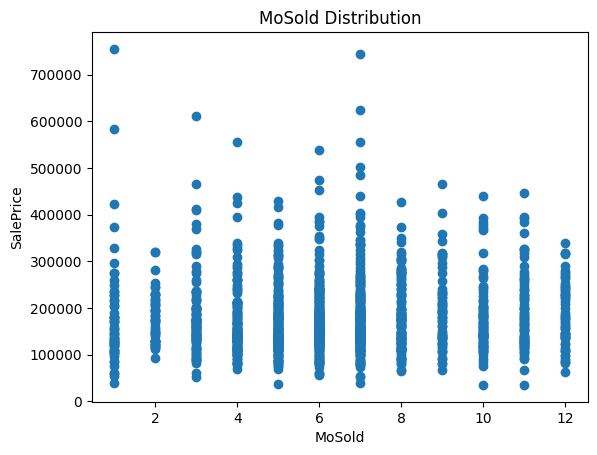

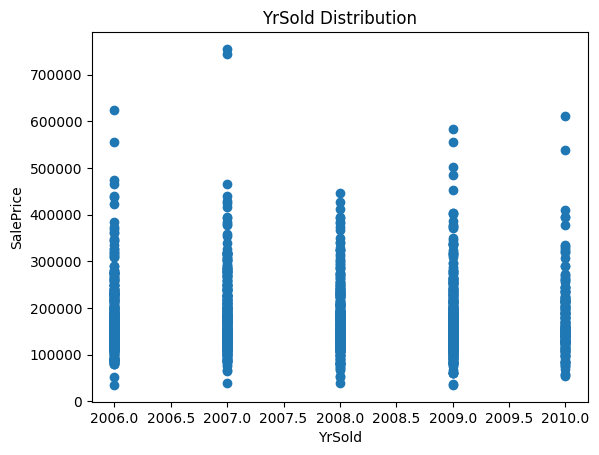

In [29]:
# Create scatter plots for each numeric feature:
for i in range(len(num_cols)):
    plt.scatter(x=num_cols[i], y = "SalePrice", data=train_data)
    plt.xlabel(xlabel=num_cols[i])
    plt.ylabel(ylabel="SalePrice")
    plt.title(label=f"{num_cols[i]} Distribution")
    plt.show()

I first tried to remove any outliers present using Z-scores, however this was causing issues with the pipeline, so it was dropped.

In [30]:
# Z-score to remove outliers:
#mean = train_data[num_cols].mean()
#std = train_data[num_cols].std()

#for i in range(len(num_cols)):
    #train_data = train_data[((train_data[num_cols[i]] - mean[i]) / std[i]).abs() <= 3]

Now let's see which features we should drop, let's first find which features have the highest NAN count in training set:

In [31]:
pd.DataFrame(train_data.isnull().sum().sort_values(ascending=False)).head(10)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


PoolQC and MiscFeature have the highest NAN values in our training set, so they will be dropped. The other features that are being dropped have almost 100% of training data points under one category, making them useless for training.

In [32]:
# Drop columns:
train_data.drop(columns=["Street", "Utilities", "PoolQC", "MiscFeature", "GarageYrBlt"], inplace=True)
test_data.drop(columns=["Street", "Utilities", "PoolQC", "MiscFeature", "GarageYrBlt"], inplace=True)

Let's handle the NAN entries, some numeric columns have NAN to represent they have none of that feature, so we can replace those with 0. The other ones can be replaced with the median of the column. For the categorical columns, simply replace NAN entries with a "None" category:

In [33]:
zero_fill_cols = ["MasVnrArea", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "BsmtFinSF1", "2ndFlrSF", "LowQualFinSF", "BsmtFullBath", "BsmtHalfBath", "Fireplaces", "GarageCars", 
                  "GarageArea", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal"]


median_fill_cols = ["LotFrontage", "LotArea", "OverallQual", "OverallCond", "YearRemodAdd", "YearBuilt", "GrLivArea", "FullBath", "HalfBath", "1stFlrSF", "BedroomAbvGr", 
                    "KitchenAbvGr", "TotRmsAbvGrd"]

train_medians = train_data[median_fill_cols].median()

train_data[zero_fill_cols] = train_data[zero_fill_cols].fillna(0)
train_data[median_fill_cols] = train_data[median_fill_cols].fillna(train_medians)
train_data = train_data.fillna("None")

test_data[zero_fill_cols] = test_data[zero_fill_cols].fillna(0)
test_data[median_fill_cols] = test_data[median_fill_cols].fillna(train_medians)
test_data = test_data.fillna("None")

We can create some new columns based off a combination of features:

In [34]:
# Feature Engineering:

train_data["HouseAge"] = train_data["YrSold"] - train_data["YearBuilt"]
train_data["RemodelAge"] = train_data["YrSold"] - train_data["YearRemodAdd"]
train_data["TotalSF"] = train_data["1stFlrSF"] + train_data["2ndFlrSF"] + train_data["BsmtFinSF1"] + train_data["BsmtFinSF2"]

train_data["TotalArea"] = train_data["GrLivArea"] + train_data["TotalBsmtSF"]
train_data["TotalBaths"] = train_data["BsmtFullBath"] + train_data["FullBath"] + 0.5 * (train_data['BsmtHalfBath'] + train_data['HalfBath'])
train_data['TotalPorchSF'] = train_data['OpenPorchSF'] + train_data['3SsnPorch'] + train_data['EnclosedPorch'] + train_data['ScreenPorch'] + train_data['WoodDeckSF']

# For test:
test_data["HouseAge"] = test_data["YrSold"] - test_data["YearBuilt"]
test_data["RemodelAge"] = test_data["YrSold"] - test_data["YearRemodAdd"]
test_data["TotalSF"] = test_data["1stFlrSF"] + test_data["2ndFlrSF"] + test_data["BsmtFinSF1"] + test_data["BsmtFinSF2"]

test_data["TotalArea"] = test_data["GrLivArea"] + test_data["TotalBsmtSF"]
test_data["TotalBaths"] = test_data["BsmtFullBath"] + test_data["FullBath"] + 0.5 * (test_data['BsmtHalfBath'] + test_data['HalfBath'])
test_data['TotalPorchSF'] = test_data['OpenPorchSF'] + test_data['3SsnPorch'] + test_data['EnclosedPorch'] + test_data['ScreenPorch'] + test_data['WoodDeckSF']

Let's create a correlation matrix to see if any features are highly correlated:

<Axes: >

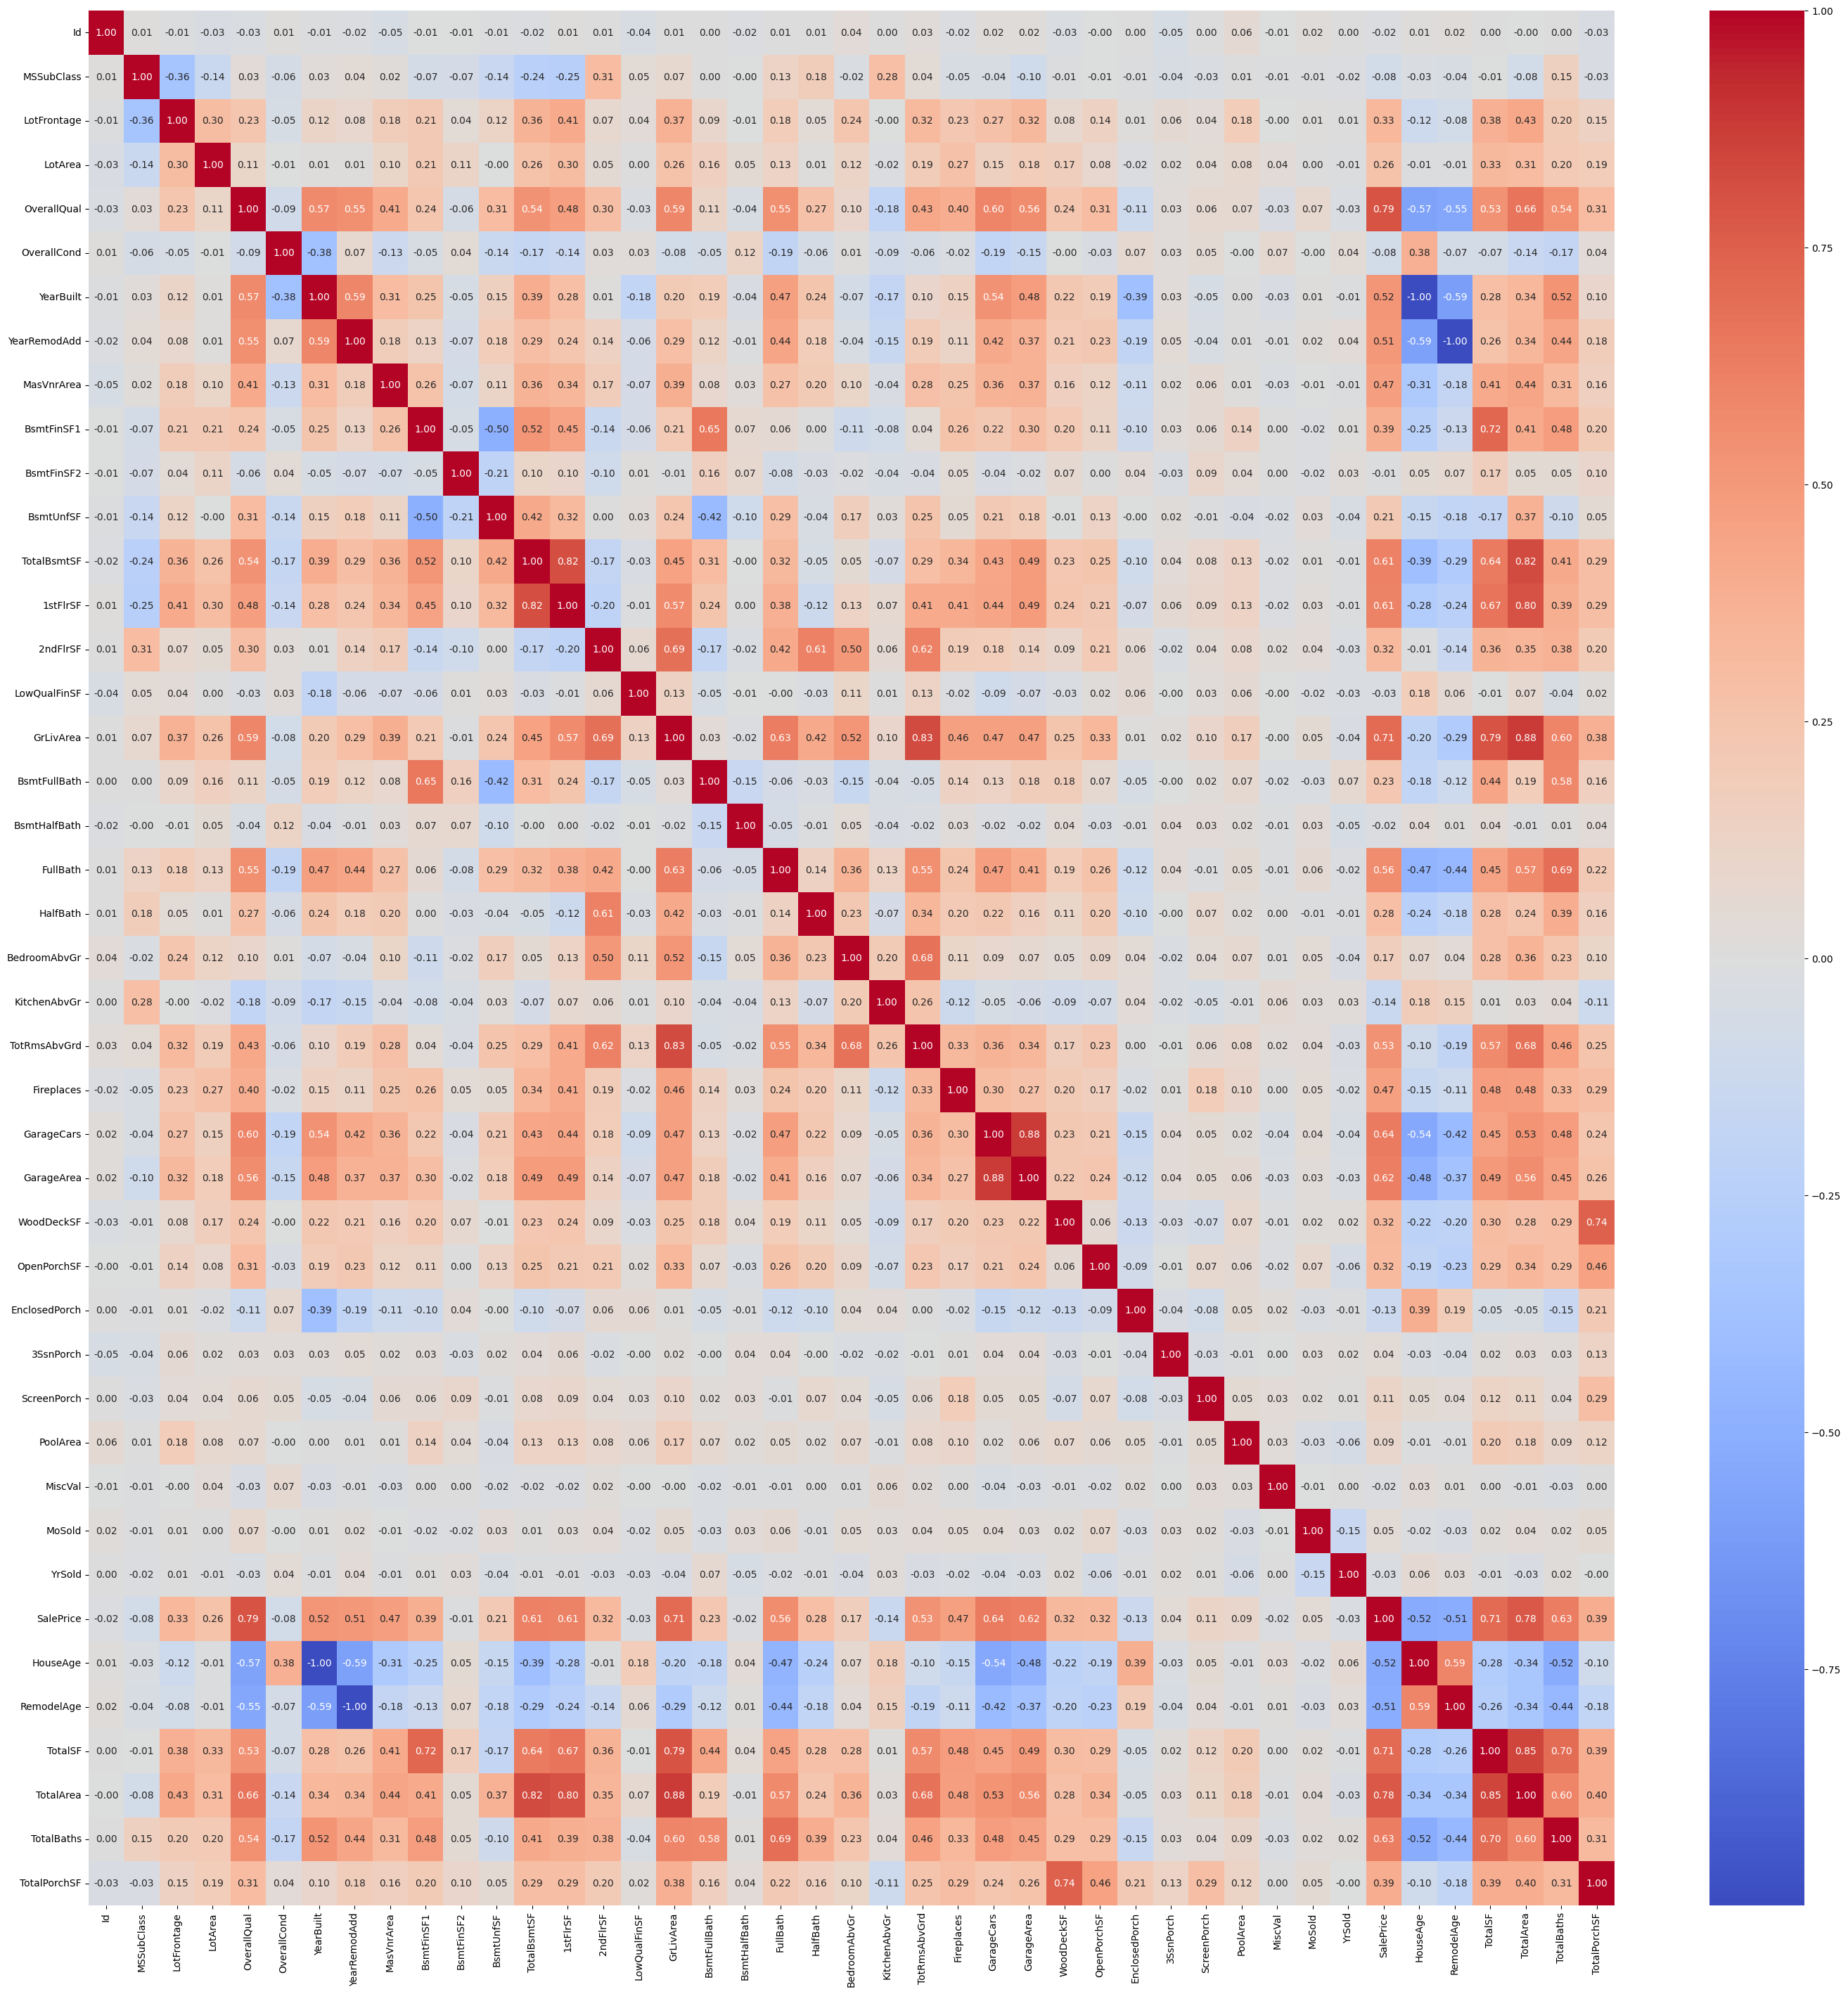

In [35]:
CM = train_data.corr(numeric_only=True)
plt.figure(figsize=(35,35))
sns.heatmap(CM, annot=True, cmap="coolwarm", fmt=".2f")

GarageCars and GarageArea have a very high correlation, r = 0.88, so we should drop one of them. GarageCars has the highest absolute correlation with SalesPrice, so we are dropping GarageArea.

In [36]:
train_data.drop(columns=["GarageArea"], inplace=True)
test_data.drop(columns=["GarageArea"], inplace=True)

In [37]:
# For normalization later
norm_cols = train_data.select_dtypes(include=["int64", "float64"]).columns.to_list()
norm_cols.remove("Id")
norm_cols.remove("SalePrice")

Let's look at the distribution of SalesPrice:

[Text(0.5, 1.0, 'Distribution of SalePrice')]

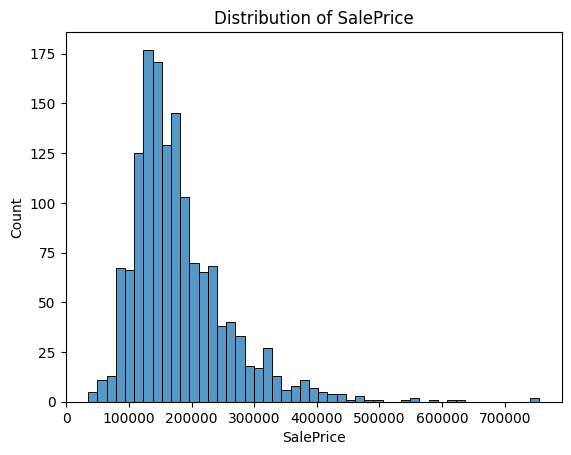

In [38]:
sns.histplot(
    train_data,
    x=train_data["SalePrice"]
).set(title="Distribution of SalePrice")

Target is right skewed, use log to transform it:

In [39]:
train_data["SalePrice"] = np.log1p(train_data["SalePrice"])

[Text(0.5, 1.0, 'Distribution of SalePrice')]

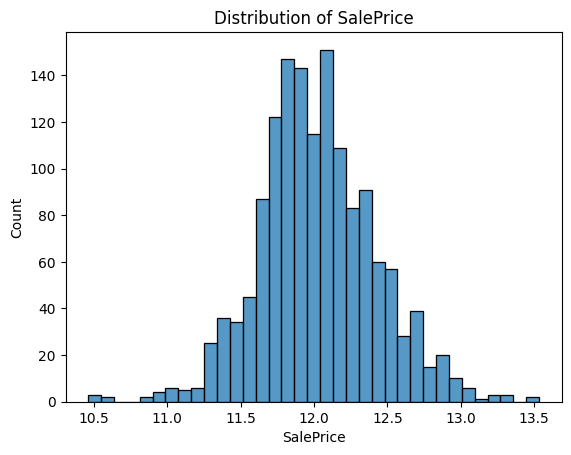

In [40]:
sns.histplot(
    train_data,
    x=train_data["SalePrice"]
).set(title="Distribution of SalePrice")

Now let's get the features that are categorical, and create indicator features for every category in each feature:

In [41]:
obj_cols = train_data.select_dtypes(include=["object"]).columns.to_list()
obj_cols

['MSZoning',
 'Alley',
 'LotShape',
 'LandContour',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'Fence',
 'SaleType',
 'SaleCondition']

In [42]:
# Creating indicator features for categorical columns in training set.
for col in obj_cols:
    categories = train_data[col].unique().tolist()

    if "None" not in categories:
        categories.append("None")

    for category in categories:
        new_col = col + "-" + category
        train_data[new_col] = train_data[col].apply(lambda x: 1 if category == str(x) else 0)
        
    train_data.drop(col, axis=1, inplace=True)

In [43]:
# Creating indicator features for categorical columns in test set.
for col in obj_cols:
    categories = test_data[col].unique().tolist()

    if "None" not in categories:
        categories.append("None")

    for category in categories:
        new_col = col + "-" + category
        test_data[new_col] = test_data[col].apply(lambda x: 1 if category == str(x) else 0)
        
    test_data.drop(col, axis=1, inplace=True)

Let's create our training data matrix, as well as create a test data matrix to see how well our model generalizes before making predictions on "test.csv".

In [44]:
t = train_data["SalePrice"].values
train_data.drop(columns=["Id", "SalePrice"], inplace=True)

X_train, X_test, t_train, t_test = train_test_split(train_data, t, test_size=0.15, random_state=1)

In [45]:
# Normalization:
mean = X_train[norm_cols].mean()
std = X_train[norm_cols].std()

X_train[norm_cols] = (X_train[norm_cols] - mean) / std
X_test[norm_cols] = (X_test[norm_cols] - mean) / std

### **Training the Models**

#### **Linear Regression**

Let's first try fitting a Linear Regression model using sklearn first:

In [23]:
lr = LinearRegression()
lr.fit(X_train, t_train)

lr_pred = lr.predict(X_test)
score = np.sqrt(mean_squared_error(t_test, lr_pred))

print(f"RMSE score with linear regression: {score}")

RMSE score with linear regression: 0.13088690895773916


This is a decent score, but we can get lower ones with other models.

#### **Random Forest**

Random Forest samples our data with replacement and creates multiple subsets. Each subset is then used to train a decision tree, and each decision tree will make a prediction. We will then take the average of all the predictions, and that will be the final prediction.

In [ ]:
rfr = RandomForestRegressor(random_state=12)
param_grid_RFR = {
    "max_depth": [5, 10, 15],
    "n_estimators": [100, 250, 500],
    "min_samples_split": [3, 5, 10]
}

rfr_cv = GridSearchCV(rfr, param_grid_RFR, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
rfr_cv.fit(X_train, t_train)

In [25]:
rfr_pred = rfr_cv.predict(X_test)
score = np.sqrt(mean_squared_error(t_test, rfr_pred))

print(f"RMSE score with Random Forest: {score}")

RMSE score with Random Forest: 0.12757045771865166


#### **XG Boost (eXtreme Gradient Boosting)**:

In [27]:
xgb = XGBRegressor(random_state=12)
param_grid_XGB = {
    "learning_rate": [0.05, 0.1, 0.2],
    "n_estimators": [300],
    "max_depth": [1, 2, 3],
    "gamma": [0, 0.1, 0.2],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

xgb_cv = GridSearchCV(xgb, param_grid_XGB, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
xgb_cv.fit(X_train, t_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 0.9, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.05, 0.1, ...], 'max_depth': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time f

In [28]:
xgb_pred = xgb_cv.predict(X_test)
score = np.sqrt(mean_squared_error(t_test, xgb_pred))

print(f"RMSE score with XGBoost: {score}")

RMSE score with XGBoost: 0.12214047122006425


#### **Ridge Regression:**

In [29]:
r = Ridge()
param_grid_R = {
    "alpha": [0.05, 0.1, 1, 3, 5, 10],
    "solver": ["auto", "svd", "cholesky", "lsqr", "sparse_cg", "sag"]
}

r_cv = GridSearchCV(r, param_grid_R, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
r_cv.fit(X_train, t_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.05, 0.1, ...], 'solver': ['auto', 'svd', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : t

In [30]:
r_pred = r_cv.predict(X_test)
score = np.sqrt(mean_squared_error(t_test, r_pred))

print(f"RMSE score with XGBoost: {score}")

RMSE score with XGBoost: 0.1262104616759583


#### **Gradient Boosting Regressor:**

In [33]:
gbr = GradientBoostingRegressor()
param_grid_gbr = {
    'max_depth': [12, 15, 20],
    'n_estimators': [200, 300, 1000],
    'min_samples_leaf': [10, 25, 50],
    'learning_rate': [0.001, 0.01, 0.1],
    'max_features': [0.01, 0.1, 0.7]
}

gbr_cv = GridSearchCV(gbr, param_grid_gbr, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
gbr_cv.fit(X_train, t_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.001, 0.01, ...], 'max_depth': [12, 15, ...], 'max_features': [0.01, 0.1, ...], 'min_samples_leaf': [10, 25, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation

In [35]:
gbr_pred = gbr_cv.predict(X_test)
score = np.sqrt(mean_squared_error(t_test, gbr_pred))

print(f"RMSE score with Gradient Boosting Regressor: {score}")

RMSE score with Gradient Boosting Regressor: 0.11348273580173597


#### **LightGBM Regressor:**

In [ ]:
lgbm = lgb.LGBMRegressor()
param_grid_lgbm = {
    'boosting_type': ['gbdt', 'dart'],
    'num_leaves': [20, 30, 40],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300]
}
lgbm_cv = GridSearchCV(lgbm, param_grid_lgbm, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
lgbm_cv.fit(X_train, t_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002131 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3871
[LightGBM] [Info] Number of data points in the train set: 1241, number of used features: 200
[LightGBM] [Info] Start training from score 12.027985


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'boosting_type': ['gbdt', 'dart'], 'learning_rate': [0.01, 0.05, ...], 'n_estimators': [100, 200, ...], 'num_leaves': [20, 30, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fol

In [39]:
lgmb_pred = lgbm_cv.predict(X_test)
score = np.sqrt(mean_squared_error(t_test, lgmb_pred))

print(f"RMSE score with LightGBM Regressor: {score}")

RMSE score with LightGBM Regressor: 0.11813029450084217


#### **CatBoost Regressor:**

In [52]:
cb = CatBoostRegressor(loss_function="RMSE", verbose=False)
param_grid_c ={
    'iterations': [100, 500, 1000],
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.5]
}

cb_cv = GridSearchCV(cb, param_grid_c, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
cb_cv.fit(X_train, t_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",CatBoostRegre...verbose=False)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'depth': [4, 6, ...], 'iterations': [100, 500, ...], 'learning_rate': [0.01, 0.05, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is 

In [53]:
cb_pred = cb_cv.predict(X_test)
score = np.sqrt(mean_squared_error(t_test, cb_pred))

print(f"RMSE score with Cat Boost Regressor: {score}")

RMSE score with Cat Boost Regressor: 0.10596014405363718


#### **Voting Regressor:**

In [50]:
vr = VotingRegressor([("Gradient Boosting Regressor", gbr_cv.best_estimator_),
                      ("LightGBM Regressor", lgbm_cv.best_estimator_), 
                      ("XGBoost Regressor", xgb_cv.best_estimator_)], 
                      weights=[2, 2, 1])

vr.fit(X_train, t_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001639 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3871
[LightGBM] [Info] Number of data points in the train set: 1241, number of used features: 200
[LightGBM] [Info] Start training from score 12.027985


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('Gradient Boosting Regressor', ...), ('LightGBM Regressor', ...), ...]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.","[2, 2, ...]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",1000
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",25


In [51]:
vr_pred = vr.predict(X_test)
score = np.sqrt(mean_squared_error(t_test, vr_pred))

print(f"RMSE score with LightGBM Regressor: {score}")

RMSE score with LightGBM Regressor: 0.11337039396258078


#### **Stacking:**

In [55]:
estimators = [
    ("Random Forest", rfr_cv.best_estimator_),
    ("XGBoost Regressor", xgb_cv.best_estimator_),
    ("Ridge Regression", r_cv.best_estimator_),
    ("Gradient Boosting Regressor", gbr_cv.best_estimator_),
    ("LightGBM Regressor", lgbm_cv.best_estimator_),
    ("Cat Boosting Regressor", cb_cv.best_estimator_)
]

In [56]:
stacking_regressor = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge()
)

stacking_regressor.fit(X_train, t_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002258 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3871
[LightGBM] [Info] Number of data points in the train set: 1241, number of used features: 200
[LightGBM] [Info] Start training from score 12.027985
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001720 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3644
[LightGBM] [Info] Number of data points in the train set: 992, number of used features: 186
[LightGBM] [Info] Start training from score 12.034959
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of t

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('Random Forest', ...), ('XGBoost Regressor', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",Ridge()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consi

In [57]:
stack_pred = stacking_regressor.predict(X_test)
score = np.sqrt(mean_squared_error(t_test, stack_pred))

print(f"RMSE score with Stacking Regressor: {score}")

RMSE score with Stacking Regressor: 0.1092212251770366


In [58]:
stacking_regressor2 = StackingRegressor(
    estimators=estimators,
    final_estimator=vr
)

stacking_regressor2.fit(X_train, t_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001276 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3871
[LightGBM] [Info] Number of data points in the train set: 1241, number of used features: 200
[LightGBM] [Info] Start training from score 12.027985
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001605 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3644
[LightGBM] [Info] Number of data points in the train set: 992, number of used features: 186
[LightGBM] [Info] Start training from score 12.034959
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of t

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('Random Forest', ...), ('XGBoost Regressor', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.","VotingRegress...hts=[2, 2, 1])"
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal 

In [59]:
stack_pred2 = stacking_regressor2.predict(X_test)
score = np.sqrt(mean_squared_error(t_test, stack_pred2))

print(f"RMSE score with Stacking Regressor 2: {score}")

RMSE score with Stacking Regressor 2: 0.12140842897303114


### **Making Predictions**

In [ ]:
feature_order = X_train.columns

test_ids = test_data["Id"]

test_data.drop(columns=["Id"], inplace = True)

test_data[norm_cols] = (test_data[norm_cols] - mean) / std

test_data = test_data.reindex(columns=feature_order, fill_value=0)

y = np.exp(stacking_regressor.predict(test_data))

pred_df = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": y
})

pred_df.to_csv("stacking_prediction.csv", index=False)